# Notebook 02 - Data Preprocessing

VisionNarrator | Stage 2

---

## 1. Objective

Raw Flickr30k
      ->
Clean + Split + Preprocess
      ->
Model-ready Dataset


## 2. Imports

Path
Pandas
NumPy
PIL
Torch
Torch Dataset/DataLoader
Torchvision


In [161]:
from pathlib import Path
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T

from sklearn.model_selection import train_test_split


## 3. Configuration

IMG_SIZE = 128
BATCH_SIZE = 32
RANDOM_SEED = 42
NUM_WORKERS = 2


In [162]:
IMG_SIZE = 128
BATCH_SIZE = 32
RANDOM_SEED = 42
NUM_WORKERS = 2

EFFECTIVE_NUM_WORKERS = 0 if platform.system() == "Windows" else NUM_WORKERS
PIN_MEMORY = torch.cuda.is_available()

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print(f"IMG_SIZE={IMG_SIZE}")
print(f"BATCH_SIZE={BATCH_SIZE}")
print(f"RANDOM_SEED={RANDOM_SEED}")
print(f"NUM_WORKERS={NUM_WORKERS}")
print(f"EFFECTIVE_NUM_WORKERS={EFFECTIVE_NUM_WORKERS}")
print(f"PIN_MEMORY={PIN_MEMORY}")


IMG_SIZE=128
BATCH_SIZE=32
RANDOM_SEED=42
NUM_WORKERS=2
EFFECTIVE_NUM_WORKERS=0
PIN_MEMORY=False


## 4. Paths

BASE_DIR
DATA_DIR
IMAGES_DIR
CAPTIONS_FILE


In [163]:
def resolve_base_dir() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src" / "data").exists():
        return cwd
    if (cwd.parent / "src" / "data").exists():
        return cwd.parent
    return cwd

BASE_DIR = resolve_base_dir()
DATA_DIR = BASE_DIR / "src" / "data"

image_dir_candidates = [
    DATA_DIR / "Images",
    DATA_DIR / "images",
    DATA_DIR / "flickr30k_images",
]
IMAGES_DIR = next((path for path in image_dir_candidates if path.exists()), image_dir_candidates[0])

caption_file_candidates = [
    DATA_DIR / "captions.txt",
    DATA_DIR / "results.csv",
]
CAPTIONS_FILE = next((path for path in caption_file_candidates if path.exists()), caption_file_candidates[0])

print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"IMAGES_DIR: {IMAGES_DIR}")
print(f"CAPTIONS_FILE: {CAPTIONS_FILE}")


BASE_DIR: C:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator
DATA_DIR: C:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\src\data
IMAGES_DIR: C:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\src\data\Images
CAPTIONS_FILE: C:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\src\data\captions.txt


## 5. Load Flickr30k

Read captions
Create image paths
Strip captions


In [164]:
def load_captions_table(captions_file: Path) -> pd.DataFrame:
    if not captions_file.exists():
        raise FileNotFoundError(
            f"Could not find captions file at {captions_file}. "
            "Place Flickr30k data inside src/data before running this notebook."
        )

    raw_df = pd.read_csv(captions_file)
    rename_map = {
        "image_name": "image",
        "filename": "image",
        "comment": "caption",
        "sentence": "caption",
        "raw": "caption",
    }
    raw_df = raw_df.rename(columns=rename_map)

    required_columns = {"image", "caption"}
    missing_columns = required_columns - set(raw_df.columns)
    if missing_columns:
        raise ValueError(
            f"Expected columns {required_columns}, found {list(raw_df.columns)}"
        )

    df = raw_df[["image", "caption"]].copy()
    df["image"] = df["image"].astype(str).str.strip()
    df["caption"] = df["caption"].astype("string").str.strip()
    df["image_path"] = df["image"].map(lambda name: IMAGES_DIR / name)
    return df


df = load_captions_table(CAPTIONS_FILE)
df.head()


,image,caption,image_path
0,1000092795.jpg,Two young guys with shaggy hair look at their ...,C:\Users\vishe\OneDrive\Desktop\VisionNarrator...
1,1000092795.jpg,"Two young , White males are outside near many ...",C:\Users\vishe\OneDrive\Desktop\VisionNarrator...
2,1000092795.jpg,Two men in green shirts are standing in a yard .,C:\Users\vishe\OneDrive\Desktop\VisionNarrator...
3,1000092795.jpg,A man in a blue shirt standing in a garden .,C:\Users\vishe\OneDrive\Desktop\VisionNarrator...
4,1000092795.jpg,Two friends enjoy time spent together .,C:\Users\vishe\OneDrive\Desktop\VisionNarrator...


## 6. Data Quality Checks

Missing captions
Missing images
Invalid images
Duplicate images


In [165]:
def is_valid_image(path: Path) -> bool:
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

missing_caption_mask = df["caption"].isna() | df["caption"].fillna("").eq("")
missing_image_mask = ~df["image_path"].map(Path.exists)

unique_existing_paths = df.loc[~missing_image_mask, "image_path"].drop_duplicates().tolist()
invalid_image_paths = [path for path in unique_existing_paths if not is_valid_image(path)]
invalid_image_set = set(invalid_image_paths)
invalid_image_mask = df["image_path"].map(lambda path: path in invalid_image_set)

exact_duplicate_pairs = df.duplicated(subset=["image", "caption"]).sum()
repeated_image_rows = df["image"].duplicated().sum()

print(f"Missing captions: {missing_caption_mask.sum()}")
print(f"Missing image rows: {missing_image_mask.sum()}")
print(f"Invalid image files: {len(invalid_image_paths)}")
print(f"Exact duplicate (image, caption) rows: {exact_duplicate_pairs}")
print(f"Repeated image rows: {repeated_image_rows} (expected because each image has multiple captions)")


Missing captions: 1
Missing image rows: 0
Invalid image files: 0
Exact duplicate (image, caption) rows: 34
Repeated image rows: 127132 (expected because each image has multiple captions)


In [166]:
clean_df = df.loc[
    ~missing_caption_mask & ~missing_image_mask & ~invalid_image_mask,
    ["image", "caption", "image_path"],
].copy()
clean_df = clean_df.drop_duplicates(subset=["image", "caption"]).reset_index(drop=True)
clean_df["image_path"] = clean_df["image_path"].map(lambda path: str(path))
clean_df["caption_word_count"] = clean_df["caption"].str.split().str.len()

print(f"Raw rows: {len(df):,}")
print(f"Clean rows: {len(clean_df):,}")
print(f"Unique images after cleaning: {clean_df['image'].nunique():,}")
clean_df.head()


Raw rows: 158,915
Clean rows: 158,880
Unique images after cleaning: 31,783


,image,caption,image_path,caption_word_count
0,1000092795.jpg,Two young guys with shaggy hair look at their ...,C:\Users\vishe\OneDrive\Desktop\VisionNarrator...,17
1,1000092795.jpg,"Two young , White males are outside near many ...",C:\Users\vishe\OneDrive\Desktop\VisionNarrator...,11
2,1000092795.jpg,Two men in green shirts are standing in a yard .,C:\Users\vishe\OneDrive\Desktop\VisionNarrator...,11
3,1000092795.jpg,A man in a blue shirt standing in a garden .,C:\Users\vishe\OneDrive\Desktop\VisionNarrator...,11
4,1000092795.jpg,Two friends enjoy time spent together .,C:\Users\vishe\OneDrive\Desktop\VisionNarrator...,7


## 7. Dataset Statistics

Number of images
Number of captions
Captions/image
etc.


In [167]:
caption_counts = clean_df.groupby("image").size()
caption_lengths = clean_df["caption_word_count"]

stats = {
    "num_images": int(clean_df["image"].nunique()),
    "num_captions": int(len(clean_df)),
    "captions_per_image_mean": float(caption_counts.mean()),
    "captions_per_image_min": int(caption_counts.min()),
    "captions_per_image_max": int(caption_counts.max()),
    "caption_words_mean": float(caption_lengths.mean()),
    "caption_words_median": float(caption_lengths.median()),
    "caption_words_p95": float(caption_lengths.quantile(0.95)),
}

pd.Series(stats)


num_images                  31783.000000
num_captions               158880.000000
captions_per_image_mean         4.998899
captions_per_image_min          3.000000
captions_per_image_max          5.000000
caption_words_mean             13.390351
caption_words_median           12.000000
caption_words_p95              23.000000
dtype: float64

## 8. Train/Val/Test Split

IMAGE-LEVEL SPLIT

Train
Val
Test


In [168]:
unique_images = clean_df[["image"]].drop_duplicates().reset_index(drop=True)

train_images, temp_images = train_test_split(
    unique_images["image"],
    test_size=0.30,
    random_state=RANDOM_SEED,
    shuffle=True,
)

val_images, test_images = train_test_split(
    temp_images,
    test_size=0.50,
    random_state=RANDOM_SEED,
    shuffle=True,
)

split_map = pd.DataFrame(
    {
        "image": list(train_images) + list(val_images) + list(test_images),
        "split": (["train"] * len(train_images))
        + (["val"] * len(val_images))
        + (["test"] * len(test_images)),
    }
)

split_df = clean_df.merge(split_map, on="image", how="inner", validate="many_to_one")

train_df = split_df[split_df["split"] == "train"].reset_index(drop=True)
val_df = split_df[split_df["split"] == "val"].reset_index(drop=True)
test_df = split_df[split_df["split"] == "test"].reset_index(drop=True)

print(f"Train images: {train_df['image'].nunique():,} | rows: {len(train_df):,}")
print(f"Val images:   {val_df['image'].nunique():,} | rows: {len(val_df):,}")
print(f"Test images:  {test_df['image'].nunique():,} | rows: {len(test_df):,}")


Train images: 22,248 | rows: 111,213
Val images:   4,767 | rows: 23,830
Test images:  4,768 | rows: 23,837


## 9. Save Splits

train.csv
val.csv
test.csv


In [169]:
train_csv = DATA_DIR / "train.csv"
val_csv = DATA_DIR / "val.csv"
test_csv = DATA_DIR / "test.csv"

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)

print(f"Saved: {train_csv}")
print(f"Saved: {val_csv}")
print(f"Saved: {test_csv}")


Saved: C:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\src\data\train.csv
Saved: C:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\src\data\val.csv
Saved: C:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\src\data\test.csv


## 10. Image Preprocessing

Resize
ToTensor
Normalize


In [170]:
base_transform = T.Compose(
    [
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ]
)

base_transform


Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)

## 11. Training Augmentation

RandomHorizontalFlip
ColorJitter
etc.


In [171]:
train_transform = T.Compose(
    [
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.RandomHorizontalFlip(p=0.5),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        T.ToTensor(),
        T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ]
)

eval_transform = base_transform

train_transform


Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)

## 12. Flickr30kDataset

image
caption


In [172]:
class Flickr30kDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        caption = row["caption"]
        return image, caption

train_dataset = Flickr30kDataset(train_df, transform=train_transform)
val_dataset = Flickr30kDataset(val_df, transform=eval_transform)
test_dataset = Flickr30kDataset(test_df, transform=eval_transform)

print(f"Train dataset size: {len(train_dataset):,}")
print(f"Val dataset size:   {len(val_dataset):,}")
print(f"Test dataset size:  {len(test_dataset):,}")


Train dataset size: 111,213
Val dataset size:   23,830
Test dataset size:  23,837


## 13. DataLoaders

train_loader
val_loader
test_loader


In [173]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print(f"Train batches: {len(train_loader):,}")
print(f"Val batches:   {len(val_loader):,}")
print(f"Test batches:  {len(test_loader):,}")


Train batches: 3,476
Val batches:   745
Test batches:  745


## 14. Verify Batch

images.shape
captions
dtype
pixel range


In [174]:
images, captions = next(iter(train_loader))

print(f"images.shape: {tuple(images.shape)}")
print(f"images.dtype: {images.dtype}")
print(f"pixel range: ({images.min().item():.3f}, {images.max().item():.3f})")
print(f"captions type: {type(captions)}")
print("Sample captions:")
for caption in list(captions)[:3]:
    print("-", caption)


images.shape: (32, 3, 128, 128)
images.dtype: torch.float32
pixel range: (-1.000, 1.000)
captions type: <class 'tuple'>
Sample captions:
- the canter in red and gold sings to his church .
- The boy with the blue helmet is playing with other boy .
- A group of bicyclists getting ready for a ride .


## 15. Visualize Final Batch

Image
Caption


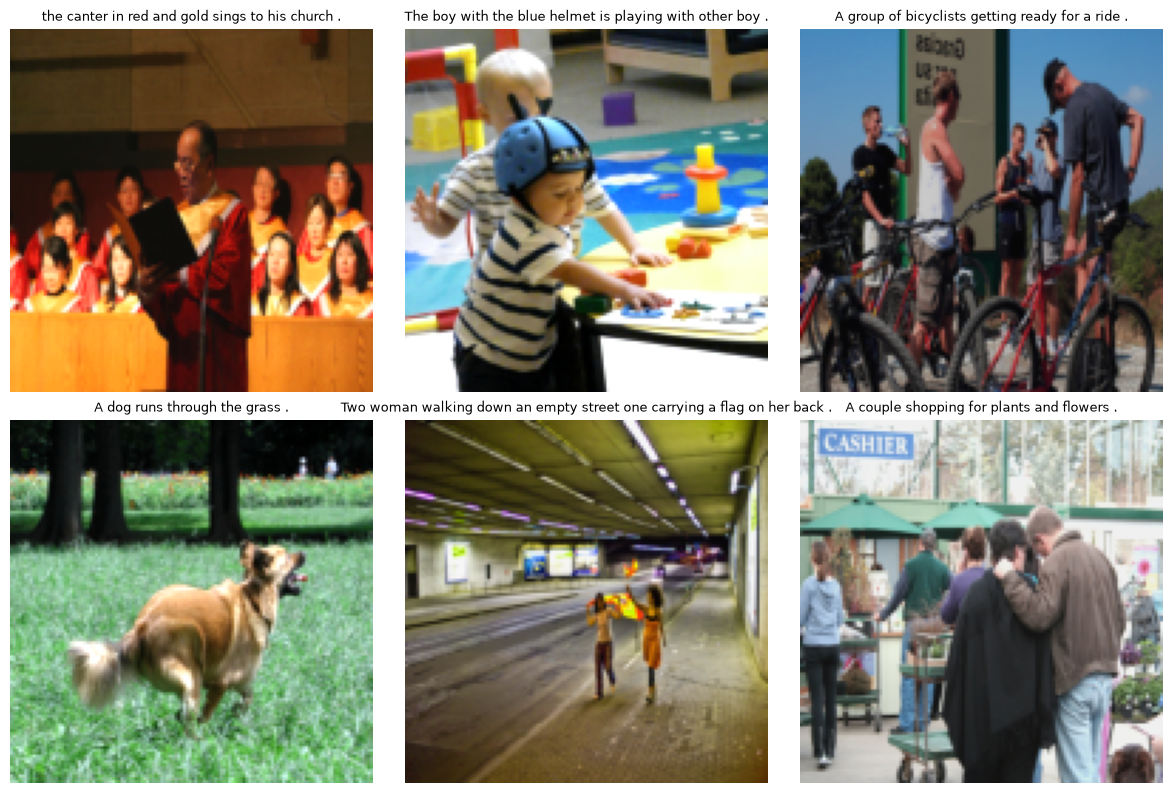

In [175]:
def denormalize_image(image_tensor: torch.Tensor) -> torch.Tensor:
    image = image_tensor.detach().cpu().clone()
    image = image * 0.5 + 0.5
    return image.clamp(0, 1)

num_examples = min(6, images.size(0))
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx in range(num_examples):
    axes[idx].imshow(denormalize_image(images[idx]).permute(1, 2, 0))
    axes[idx].set_title(captions[idx], fontsize=9)
    axes[idx].axis("off")

for idx in range(num_examples, len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()


## 16. Final Sanity Checks

No leakage
No missing files
Correct split
Correct tensor shape


In [176]:
train_image_set = set(train_df["image"].unique())
val_image_set = set(val_df["image"].unique())
test_image_set = set(test_df["image"].unique())

no_leakage = (
    train_image_set.isdisjoint(val_image_set)
    and train_image_set.isdisjoint(test_image_set)
    and val_image_set.isdisjoint(test_image_set)
)

split_coverage_ok = len(train_image_set | val_image_set | test_image_set) == clean_df["image"].nunique()
missing_split_files = (
    (~train_df["image_path"].map(lambda p: Path(p).exists())).sum()
    + (~val_df["image_path"].map(lambda p: Path(p).exists())).sum()
    + (~test_df["image_path"].map(lambda p: Path(p).exists())).sum()
)
shape_ok = tuple(images.shape[1:]) == (3, IMG_SIZE, IMG_SIZE)

print(f"No leakage: {no_leakage}")
print(f"Missing files across saved splits: {missing_split_files}")
print(f"Correct split coverage: {split_coverage_ok}")
print(f"Correct tensor shape: {shape_ok}")

assert no_leakage, "Image leakage detected between splits."
assert missing_split_files == 0, "Some split rows point to missing image files."
assert split_coverage_ok, "Not all cleaned images are covered by the split."
assert shape_ok, "Batch tensor shape does not match (3, IMG_SIZE, IMG_SIZE)."


No leakage: True
Missing files across saved splits: 0
Correct split coverage: True
Correct tensor shape: True
